# Tutorial – Session 6

## Fordelinger af stikprøvestørrelser (Sampling Distributions)

### Den Centrale Grænseværdisætning og Simulationer
I denne tutorial bygger vi videre på vores viden om fordelinger ved at se på, hvordan **stikprøvegennemsnit** opfører sig. Formålet er at forstå et af de absolut vigtigste koncepter i statistik: Den Centrale Grænseværdisætning (Central Limit Theorem - CLT).
Vi vil bruge Python til at simulere trækning af stikprøver, så vi visuelt kan se, hvordan fordelingen af gennemsnit bliver formet som en klokkekurve (normalfordeling), selvom den oprindelige population ikke er normalfordelt.

---

## 1. Introduktion og Setup
Før vi begynder at simulere stikprøver, skal vi opsætte vores miljø. Vi importerer de nødvendige biblioteker til at trække tilfældige tal, beregne gennemsnit, plotte fordelingerne og arbejde med den teoretiske normalfordeling.
Vi får brug for:
- `numpy` til at generere tilfældige tal og beregne gennemsnit.
- `matplotlib.pyplot` til at visualisere fordelingerne med histogrammer.
- `scipy.stats` til at arbejde med de teoretiske fordelinger (f.eks. `expon` til at skabe en skæv population og `norm` til at beregne sandsynligheder for stikprøvegennemsnittet).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon

# Sæt et seed for reproducerbarhed (så vi får de samme tilfældige tal hver gang)
np.random.seed(42)

# Opsætning af pænere plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('ggplot')

## 2. Population vs. Stikprøve (Simulation)
Forskellen mellem en **population** (hele datasættet eller alle mulige udfald) og en **stikprøve** (et tilfældigt udsnit af populationen) er fundamental. 
Lad os starte med at generere en "skæv" fordeling. Her bruger vi en eksponentialfordeling til at repræsentere vores sande population.

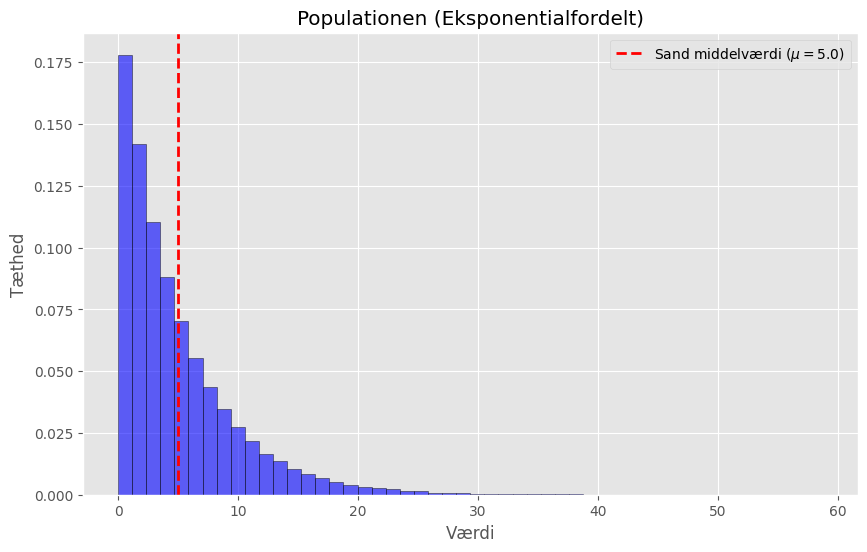

In [2]:
# Lad os definere en population baseret på eksponentialfordelingen
# scale-parameteren er 1/lambda, som også er middelværdien (mu) for eksponentialfordelingen.
mu_pop = 5.0
sigma_pop = 5.0 # For en eksponentialfordeling er mu = sigma

# Vi trækker 100.000 værdier for at simulere den "sande" population
population = expon.rvs(scale=mu_pop, size=100000)

plt.hist(population, bins=50, density=True, alpha=0.6, color='blue', edgecolor='black')
plt.title("Populationen (Eksponentialfordelt)")
plt.xlabel("Værdi")
plt.ylabel("Tæthed")
plt.axvline(mu_pop, color='red', linestyle='dashed', linewidth=2, label=f"Sand middelværdi ($\\mu={mu_pop}$)")
plt.legend()
plt.show()

Når vi trækker en enkelt stikprøve (sample) fra populationen, får vi et lille, tilfældigt udpluk. 

In [3]:
# Træk en stikprøve på 30 observationer
n = 30
sample = np.random.choice(population, size=n, replace=False)

sample_mean = np.mean(sample)
print(f"Stikprøvegennemsnit (x-bar): {sample_mean:.2f}")

Stikprøvegennemsnit (x-bar): 4.29


Hver gang du trækker en ny stikprøve, vil gennemsnittet variere. Dette kaldes *stikprøvevariation*.
## 3. Den Centrale Grænseværdisætning (CLT) i praksis
Den Centrale Grænseværdisætning (CLT) fortæller os, at uanset populationens fordeling vil fordelingen af *stikprøvegennemsnittene* nærme sig en normalfordeling, når stikprøvestørrelsen ($n$) bliver stor (typisk når $n \ge 30$).
Lad os teste dette ved at køre en simulation: Vi trækker 10.000 stikprøver fra vores eksponentialfordelte population og ser på fordelingen af deres gennemsnit for forskellige stikprøvestørrelser ($n=2$, $n=10$ og $n=30$).

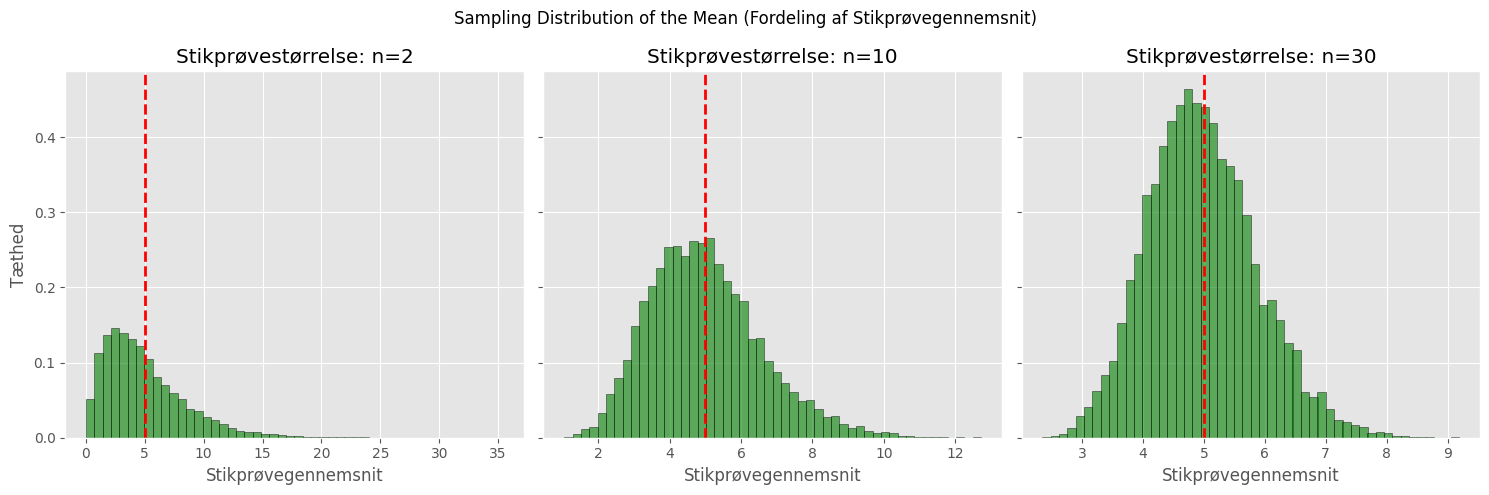

In [4]:
num_samples = 10000
sample_sizes = [2, 10, 30]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, n in enumerate(sample_sizes):
    # Generer 10.000 stikprøver af størrelse n, og beregn gennemsnittet for hver
    sample_means = [np.mean(np.random.choice(population, size=n, replace=False)) for _ in range(num_samples)]
    
    # Plot histogrammet for stikprøvegennemsnittene
    axes[i].hist(sample_means, bins=50, density=True, alpha=0.6, color='green', edgecolor='black')
    axes[i].set_title(f"Stikprøvestørrelse: n={n}")
    axes[i].set_xlabel("Stikprøvegennemsnit")
    axes[i].axvline(mu_pop, color='red', linestyle='dashed', linewidth=2)

axes[0].set_ylabel("Tæthed")
plt.suptitle("Sampling Distribution of the Mean (Fordeling af Stikprøvegennemsnit)")
plt.tight_layout()
plt.show()

Vi kan se, at selvom den oprindelige population er skæv, bliver fordelingen af gennemsnit mere og mere klokkeformet og koncentreret omkring den sande middelværdi ($\mu = 5$), efterhånden som $n$ stiger. Det er præcis, hvad CLT lover os!
## 4. Standardfejl (Standard Error - SE)
Spredningen (standardafvigelsen) i stikprøvegennemsnittenes fordeling kaldes **Standardfejlen** (Standard Error, SE). Ifølge teorien er standardfejlen givet ved:

$$ SE = \frac{\sigma}{\sqrt{n}} $$

hvor $\sigma$ er populationens standardafvigelse.
Lad os sammenligne den *empiriske* standardfejl fra vores simulation ($n=30$) med den *teoretiske* standardfejl:

In [5]:
n_test = 30
sample_means_30 = [np.mean(np.random.choice(population, size=n_test, replace=False)) for _ in range(num_samples)]

# Empirisk SE (fra simulationen)
empirisk_se = np.std(sample_means_30, ddof=1)

# Teoretisk SE
teoretisk_se = sigma_pop / np.sqrt(n_test)

print(f"Empirisk Standardfejl (simulation): {empirisk_se:.4f}")
print(f"Teoretisk Standardfejl (formel):    {teoretisk_se:.4f}")

Empirisk Standardfejl (simulation): 0.9069
Teoretisk Standardfejl (formel):    0.9129


Som vi kan se, er simulationen i god overensstemmelse med teorien. Jo større $n$ er, des mindre bliver usikkerheden (SE), hvilket forklarer, hvorfor fordelingen for $n=30$ i plottet ovenfor var meget snævrere end for $n=2$.

## 5. Beregning af sandsynligheder for stikprøvegennemsnit

Fordi vi via CLT ved, at stikprøvegennemsnittet er (tilnærmelsesvist) normalfordelt for store $n$, kan vi bruge normalfordelingen til at beregne sandsynligheder. Stikprøvegennemsnittet $\bar{X}\sim N(\mu, \frac{\sigma}{\sqrt{n}})$.

Antag, at vi har en population med middelværdi $\mu = 50$ og standardafvigelse $\sigma = 15$. Vi trækker en stikprøve på $n = 36$. Hvad er sandsynligheden for, at stikprøvegennemsnittet $\bar{x}$ er større end 55?

### I Python

Her beregner vi først standardfejlen (SE) og bruger derefter `norm.sf` (survival function, som svarer til $1 - \text{CDF}$ eller $P(\bar{X} > x)$):

In [6]:
mu_prob = 50
sigma_prob = 15
n_prob = 36
x_bar = 55

# Beregn Standardfejl
SE = sigma_prob / np.sqrt(n_prob)

# P(X-bar > 55)
prob = norm.sf(x_bar, loc=mu_prob, scale=SE)
print(f"Sandsynligheden for at x-bar er over {x_bar} er: {prob:.4f}")

Sandsynligheden for at x-bar er over 55 er: 0.0228


### I WolframAlpha
For at løse dette i WolframAlpha, kan du angive forespørgslen direkte. Du skal blot huske, at du skal bruge normalfordelingen, men ændre standardafvigelsen til standardfejlen:

$$\text{Standardfejl (SE)} = \frac{15}{\sqrt{36}} = \frac{15}{6} = 2.5$$

I WolframAlpha kan du skrive:

```
P(X > 55) NormalDistribution(50, 2.5)
```

Dette giver os den samme løsning.

## 6. Opsummering
I denne session har vi gennem simulation bevist et af de mest fundamentale principper i statistikken.
**Hvad du nu skal kunne:**
- Forstå forskellen på populationens spredning ($\sigma$) og stikprøvegennemsnittenes spredning (Standard Error, $SE$).
- Forklare, hvordan Den Centrale Grænseværdisætning (CLT) medfører, at gennemsnittene af stikprøver nærmer sig en normalfordeling, selvom de rå data ikke er normalfordelte.
- Beregne standardfejlen ud fra populationens standardafvigelse og stikprøvestørrelsen ($SE = \frac{\sigma}{\sqrt{n}}$).
- Bruge Python (især `scipy.stats.norm`) og WolframAlpha til at beregne sandsynligheder for et stikprøvegennemsnit, når populationens parametre og stikprøvens størrelse er kendt.